In [1]:
import scanpy as sc
import os
import pandas as pd
from singletCode import check_sample_sheet, get_singlets
import harmonypy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
from scipy.stats import mannwhitneyu
import scclr

/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
barcode = pd.read_csv("/home/gzu5140/Keerthana_b1042/TwINFER/real_data/cellTag3_data/all_samples.csv")
h5_dir = "/home/gzu5140/Keerthana_b1042/TwINFER/real_data/celltag_3_geo_data/"
output_path = "/home/gzu5140/Keerthana_b1042/analysis_data/celltag_3/"

In [3]:
singlet_cells_list = pd.read_csv("/home/gzu5140/Keerthana_b1042/TwINFER/real_data/celltag_3_geo_data/celltag_singlet_list.csv")

In [4]:
h5_dir = "/home/gzu5140/Keerthana_b1042/TwINFER/real_data/celltag_3_geo_data/"

# ── 1. Load all h5 files ──────────────────────────────────────────────────────
def load_and_tag(path, key):
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs_names = [f"{key}:{bc}" for bc in adata.obs_names]
    return adata

d2_rna5 = sc.read_10x_h5(f"{h5_dir}GSM6681127_d2_5_filtered_feature_bc_matrix.h5")
d2_rna5.var_names_make_unique()
d2_rna5.obs['cellID'] = d2_rna5.obs_names.str.replace(r'-\d+$', '', regex=True)

d5_rna1 = sc.concat([
    load_and_tag(f"{h5_dir}GSM6681128_d5_1_filtered_feature_bc_matrix.h5", 's1'),
    load_and_tag(f"{h5_dir}GSM6681129_d5_2_filtered_feature_bc_matrix.h5", 's2'),
    load_and_tag(f"{h5_dir}GSM6681130_d5_3_filtered_feature_bc_matrix.h5", 's3'),
    load_and_tag(f"{h5_dir}GSM6681131_d5_4_filtered_feature_bc_matrix.h5", 's4'),
])
d5_rna1.var_names_make_unique()
d5_rna1.obs['cellID'] = d5_rna1.obs_names.str.split(':').str[-1].str.replace(r'-\d+$', '', regex=True)

d5_rna2 = sc.concat([
    load_and_tag(f"{h5_dir}GSM6681132_d5_5_filtered_feature_bc_matrix.h5", 's5'),
    load_and_tag(f"{h5_dir}GSM6681133_d5_6_filtered_feature_bc_matrix.h5", 's6'),
    load_and_tag(f"{h5_dir}GSM6681134_d5_7_filtered_feature_bc_matrix.h5", 's7'),
    load_and_tag(f"{h5_dir}GSM6681135_d5_8_filtered_feature_bc_matrix.h5", 's8'),
])
d5_rna2.var_names_make_unique()
d5_rna2.obs['cellID'] = d5_rna2.obs_names.str.split(':').str[-1].str.replace(r'-\d+$', '', regex=True)

samples_raw = {
    "d2-RNA-5": d2_rna5,
    "d5-RNA-1": d5_rna1,
    "d5-RNA-2": d5_rna2,
}


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/annd

[d2-RNA-5] Singlet cell IDs to keep: 1476
[d2-RNA-5] Cells before: 5515 → after: 1476
[d5-RNA-1] Singlet cell IDs to keep: 11478
[d5-RNA-1] Cells before: 38337 → after: 11524
[d5-RNA-2] Singlet cell IDs to keep: 11783
[d5-RNA-2] Cells before: 38932 → after: 11815


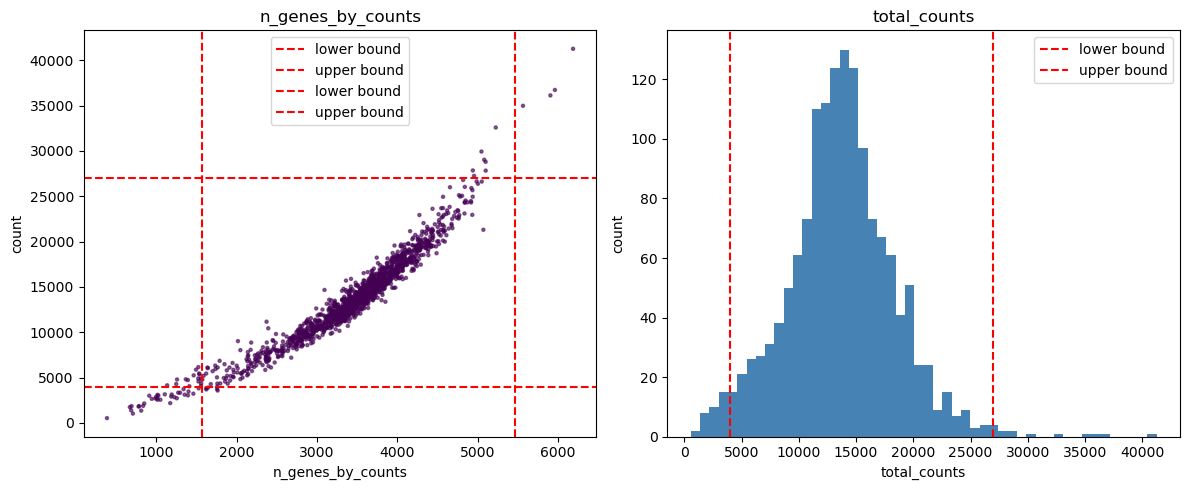

[d2-RNA-5] Outlier breakdown:
  total_counts outliers:      353
  n_genes_by_counts outliers: 351
  high mito%:                 0
[d2-RNA-5] QC: 1476 → 1079 cells (397 removed)


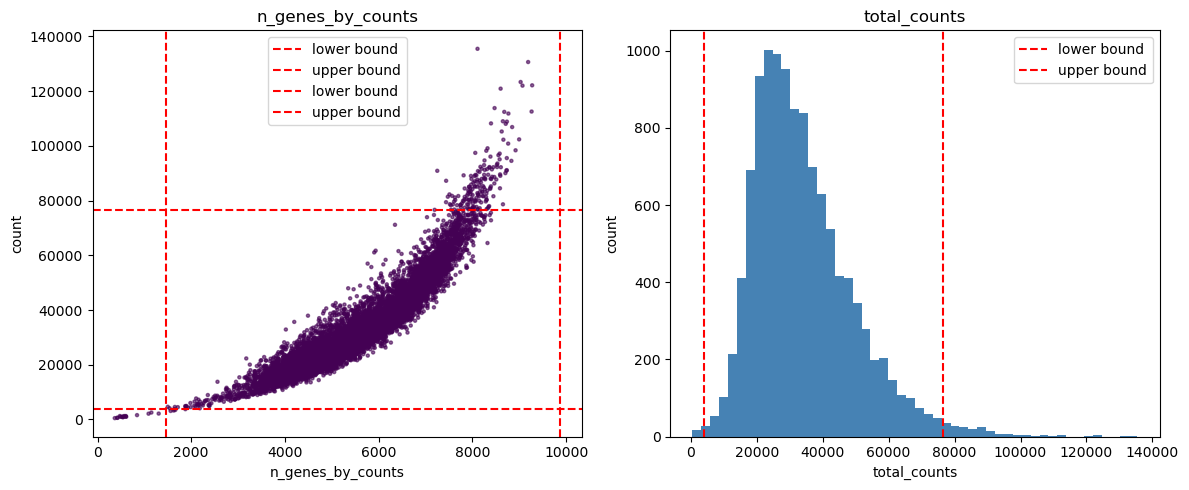

[d5-RNA-1] Outlier breakdown:
  total_counts outliers:      2030
  n_genes_by_counts outliers: 1583
  high mito%:                 0
[d5-RNA-1] QC: 11524 → 8990 cells (2534 removed)


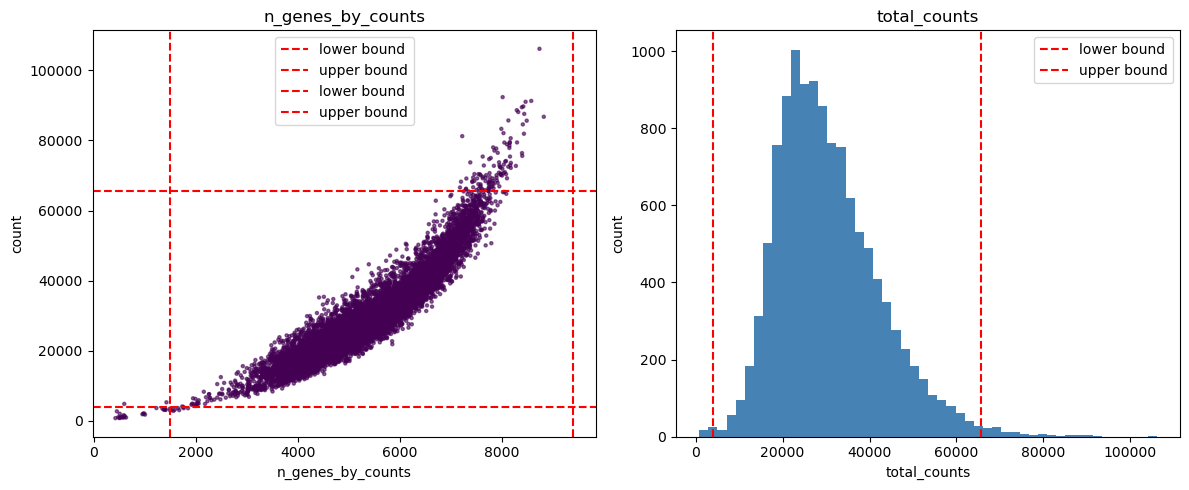

[d5-RNA-2] Outlier breakdown:
  total_counts outliers:      2079
  n_genes_by_counts outliers: 1494
  high mito%:                 0
[d5-RNA-2] QC: 11815 → 9377 cells (2438 removed)


In [5]:
# ── 2. Filter to singlets + annotate barcodes ─────────────────────────────────
def filter_and_annotate_adata(adata, metadata_df, sample_name):
    cell_ids_to_keep = (
        metadata_df[metadata_df['sample'] == sample_name]['cellID']
        .unique().tolist()
    )
    
    adata = adata.copy()
    if 'cellID' not in adata.obs.columns:
        adata.obs['cellID'] = adata.obs_names.str.replace(r'-\d+$', '', regex=True)
    mask = adata.obs['cellID'].isin(cell_ids_to_keep)
    # mask = adata.obs['cellID'].isin(cell_ids_to_keep)
    adata_filtered = adata[mask].copy()

    print(f"[{sample_name}] Singlet cell IDs to keep: {len(cell_ids_to_keep)}")
    print(f"[{sample_name}] Cells before: {adata.n_obs} → after: {adata_filtered.n_obs}")

    sample_meta = metadata_df[metadata_df['sample'] == sample_name]
    barcode_agg = (
        sample_meta.groupby('cellID')['barcode']
        .apply(list).rename('lineage_barcodes')
    )
    meta_per_cell = (
        sample_meta.groupby('cellID')
        .agg(nUMI=('nUMI', 'first'), label=('label', 'first'))
        .join(barcode_agg)
    )
    adata_filtered.obs = adata_filtered.obs.join(meta_per_cell, on='cellID', how='left')
    return adata_filtered

def is_outlier(adata, metric, nmads=5):
    M = adata.obs[metric]
    med = np.median(M)
    mad_val = median_abs_deviation(M)
    return (M < med - nmads * mad_val) | (M > med + nmads * mad_val)
from scipy.stats import median_abs_deviation
import numpy as np

def get_outlier_bounds(adata, metric, nmads=5):
    M = adata.obs[metric]
    med = np.median(M)
    mad_val = median_abs_deviation(M)
    lower = med - nmads * mad_val
    upper = med + nmads * mad_val
    return lower, upper

def qc_mad_filter(adata, sample_name, nmads=5, max_pct_mito=20):
    adata.var['mt'] = adata.var_names.str.startswith('MT-')  # use 'mt-' for mouse
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    before = adata.n_obs

    # outlier_counts = is_outlier(adata, 'total_counts', nmads)
    # outlier_genes  = is_outlier(adata, 'n_genes_by_counts', nmads)
    # outlier_mito   = adata.obs['pct_counts_mt'] > max_pct_mito
    outlier_counts = (
        is_outlier(adata, 'total_counts', nmads=2) |
        (adata.obs['total_counts'] < 4000)
    )

    outlier_genes = (
        is_outlier(adata, 'n_genes_by_counts', nmads=2) |
        (adata.obs['n_genes_by_counts'] < 200)
    )

    outlier_mito = adata.obs['pct_counts_mt'] > 10

    low_genes, high_genes = get_outlier_bounds(adata, 'n_genes_by_counts', nmads)
    low_genes = max(low_genes, 200)
    low_counts, high_counts = get_outlier_bounds(adata, 'total_counts', nmads)
    low_counts = max(low_counts, 4000)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ── n_genes_by_counts ─────────────────────────────
    axes[0].scatter(
        adata.obs["n_genes_by_counts"],
        adata.obs["total_counts"],
        c=adata.obs["pct_counts_mt"],
        s=5,
        alpha=0.6,
        cmap="viridis"
    )
    axes[0].axvline(low_genes, color="red", linestyle="--", label="lower bound")
    axes[0].axvline(high_genes, color="red", linestyle="--", label="upper bound")
    axes[0].axhline(low_counts, color="red", linestyle="--", label="lower bound")
    axes[0].axhline(high_counts, color="red", linestyle="--", label="upper bound")
    axes[0].set_title('n_genes_by_counts')
    axes[0].set_xlabel('n_genes_by_counts')
    axes[0].set_ylabel('count')
    axes[0].legend()

    # ── total_counts ─────────────────────────────
    axes[1].hist(adata.obs['total_counts'], bins=50, color="steelblue")
    axes[1].axvline(low_counts, color="red", linestyle="--", label="lower bound")
    axes[1].axvline(high_counts, color="red", linestyle="--", label="upper bound")
    axes[1].set_title('total_counts')
    axes[1].set_xlabel('total_counts')
    axes[1].set_ylabel('count')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print(f"[{sample_name}] Outlier breakdown:")
    print(f"  total_counts outliers:      {outlier_counts.sum()}")
    print(f"  n_genes_by_counts outliers: {outlier_genes.sum()}")
    print(f"  high mito%:                 {outlier_mito.sum()}")
    
    fail_any = outlier_counts | outlier_genes | outlier_mito
    adata.obs['qc_pass'] = ~fail_any

    adata_filt = adata[adata.obs['qc_pass']].copy()

    print(f"[{sample_name}] QC: {before} → {adata_filt.n_obs} cells ({before - adata_filt.n_obs} removed)")
    return adata_filt

# Usage
# ── 3. QC filtering ───────────────────────────────────────────────────────────
def qc_filter(adata, sample_name,
              min_genes=200, max_genes=6000,
              min_counts=500, max_counts=30000,
              max_pct_mito=20):
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    before = adata.n_obs

    # Build individual boolean masks for each criterion
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].hist(adata.obs['n_genes_by_counts'])
    axes[0].axvline(min_genes, linestyle = "--")
    axes[0].axvline(max_genes, linestyle = "--")
    axes[0].set_title('n_genes_by_counts')
    axes[0].set_xlabel('n_genes_by_counts')
    axes[0].set_ylabel('count')

    axes[1].hist(adata.obs['total_counts'])
    axes[1].axvline(min_counts, linestyle = "--")
    axes[1].axvline(max_counts, linestyle = "--")
    axes[1].set_title('total_counts')
    axes[1].set_xlabel('total_counts')
    axes[1].set_ylabel('count')

    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    sc = ax

    ax.axvline(min_genes, linestyle="--", color="red")
    ax.axvline(max_genes, linestyle="--", color="red")
    ax.axhline(min_counts, linestyle="--", color="blue")
    ax.axhline(max_counts, linestyle="--", color="blue")

    plt.colorbar(sc, ax=ax, label="% mitochondrial")
    ax.set_xlabel("n_genes_by_counts")
    ax.set_ylabel("total_counts")
    ax.set_title("QC scatter colored by mito%")

    plt.tight_layout()
    plt.show()

    fail_min_genes  = adata.obs['n_genes_by_counts'] < min_genes
    fail_max_genes  = adata.obs['n_genes_by_counts'] > max_genes
    fail_min_counts = adata.obs['total_counts'] < min_counts
    fail_max_counts = adata.obs['total_counts'] > max_counts
    fail_mito       = adata.obs['pct_counts_mt'] > max_pct_mito
    
    # Report how many cells fail each criterion (not mutually exclusive —
    # a cell can fail more than one)
    print(f"[{sample_name}] QC breakdown (before filtering, {before} cells):")
    print(f"  Too few genes   (<{min_genes}):        {fail_min_genes.sum()}")
    print(f"  Too many genes  (>{max_genes}):        {fail_max_genes.sum()}")
    print(f"  Too few counts  (<{min_counts}):        {fail_min_counts.sum()}")
    print(f"  Too many counts (>{max_counts}):        {fail_max_counts.sum()}")
    print(f"  High mito%      (>{max_pct_mito}%):     {fail_mito.sum()}")

    fail_any = fail_min_genes | fail_max_genes | fail_min_counts | fail_max_counts | fail_mito
    print(f"  Total unique cells failing ≥1 criterion: {fail_any.sum()}")

    keep = ~fail_any
    adata = adata[keep].copy()
    print(f"[{sample_name}] QC: {before} → {adata.n_obs} cells ({before - adata.n_obs} removed)")
    return adata


filtered = {
    name: filter_and_annotate_adata(adata, singlet_cells_list, name)
    for name, adata in samples_raw.items()
}

qc_passed = {
    name: qc_mad_filter(adata, name,
                    # min_genes=200, max_genes=6000,
                    # min_counts=500, max_counts=30000,
                    max_pct_mito=10)
    for name, adata in filtered.items()
}

# ── 5. Concatenate ────────────────────────────────────────────────────────────
for name in qc_passed:
    qc_passed[name].var_names_make_unique()



In [6]:
adata = sc.concat(qc_passed, label='sample', merge='same')
print(f"adata: {adata.n_obs} cells × {adata.n_vars} genes")
adata.obs['match_key'] = adata.obs['sample'].astype(str) + '_' + adata.obs_names.astype(str)
adata.obs['match_key'] = adata.obs['match_key'].str[:-2]

adata: 19446 cells × 31055 genes


In [7]:
# ── 1. Parse CSV, keeping barcode+suffix together ────────────────────────────
clone_df = pd.read_csv('/home/gzu5140/Keerthana_b1042/TwINFER/real_data/celltag_3_geo_data/hsc.rna&atac.r1&2_master_v2.csv')

split_bc = clone_df['cell.bc'].str.rsplit('-', n=2, expand=True)
clone_df['sample_assay'] = split_bc[0]
clone_df['barcode']      = split_bc[1]           # raw 16bp barcode, no suffix
clone_df['suffix']       = split_bc[2]           # "1","2","3","4"

sa_split = clone_df['sample_assay'].str.rsplit('-', n=1, expand=True)
clone_df['sample'] = sa_split[0]   # "d2_5","d5r1","d5r2"
clone_df['assay']  = sa_split[1]   # "rna"

clone_rna = clone_df[clone_df['assay'] == 'rna'].copy()

# ── 2. Reconstruct the s1..s8 lane label to match your load_and_tag scheme ──
lane_map = {
    ('d2_5', '1'): None,          # d2_5 loaded as single h5, no lane prefix used
    ('d5r1', '1'): 's1', ('d5r1', '2'): 's2', ('d5r1', '3'): 's3', ('d5r1', '4'): 's4',
    ('d5r2', '1'): 's5', ('d5r2', '2'): 's6', ('d5r2', '3'): 's7', ('d5r2', '4'): 's8',
}
clone_rna['lane'] = clone_rna.apply(lambda r: lane_map.get((r['sample'], r['suffix'])), axis=1)

# ── 3. Build match_key matching each combined sub-object's obs_names format ─
# d2_5: obs_names = raw barcode with original -N suffix (untouched)
# d5_rna1 / d5_rna2: obs_names = "sX:barcode-N" (prefix + original suffix kept in obs_names,
#                     but cellID column has suffix stripped — use obs_names, not cellID!)

sample_map = {'d2_5': 'd2-RNA-5', 'd5r1': 'd5-RNA-1', 'd5r2': 'd5-RNA-2'}
clone_rna['sample_combined'] = clone_rna['sample'].map(sample_map)

def build_match_key(row):
    if row['sample'] == 'd2_5':
        return f"{row['sample_combined']}_{row['barcode']}"
    else:
        return f"{row['sample_combined']}_{row['lane']}:{row['barcode']}"

clone_rna['match_key'] = clone_rna.apply(build_match_key, axis=1)

print("Duplicates:", clone_rna['match_key'].duplicated().sum())  # should be 0 now

# ── 4. Build the same key structure from combined.obs_names (NOT cellID) ────
key_to_clone = clone_rna.set_index('match_key')['clone.id']
adata.obs['clone_id'] = adata.obs['match_key'].map(key_to_clone)

n_matched = adata.obs['clone_id'].notna().sum()
print(f"Matched {n_matched}/{adata.n_obs} cells to a clone ID")
print(adata.obs.groupby('sample')['clone_id'].apply(lambda x: x.notna().sum()))

Duplicates: 0
Matched 14361/19446 cells to a clone ID
sample
d2-RNA-5     458
d5-RNA-1    6825
d5-RNA-2    7078
Name: clone_id, dtype: int64


/tmp/ipykernel_2621645/2514523858.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby('sample')['clone_id'].apply(lambda x: x.notna().sum()))


In [8]:
sc.pp.filter_genes(adata, min_cells=3)

In [15]:
"""
scRNA-seq normalization comparison toolkit
============================================
Provides several normalization strategies plus diagnostics to compare
which one is best suited for:
  1. PCA-based cell-cell distances
  2. Gene-gene correlation analysis

Requires: scanpy >= 1.9 (for Pearson residual methods), numpy, pandas,
scipy, scikit-learn

Install if needed:
    pip install scanpy scikit-learn scipy pandas

MEMORY NOTES (important for large datasets):
- Every normalize_* function calls adata.copy(), which duplicates the
  WHOLE object including all layers. If you run several normalizations
  back-to-back in the same session, `del` the previous result and call
  gc.collect() before running the next one, or you'll hold multiple
  full copies in memory simultaneously.
- Functions that call .toarray() (normalize_median_of_ratios,
  proportionality_metrics, unrelated_gene_correlation_spread) densify
  the matrix, which can blow up memory fast on large cell x gene
  matrices. If you only care about correlation among a small gene
  panel (e.g. a dozen TFs), use `subset_to_genes()` below FIRST to
  shrink adata before calling any function that densifies — running
  correlation/proportionality diagnostics on the full transcriptome
  when you only need 12 genes is the single biggest avoidable memory
  cost in this pipeline.
- PCA-based diagnostics (pc_depth_correlation, downsampling_stability)
  genuinely need the full (or HVG-restricted) matrix, since PCA
  structure depends on the whole transcriptome — don't subset those
  to just your gene panel.
"""

import gc
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import pearsonr, spearmanr
from scipy.sparse import issparse


def subset_to_genes(adata, gene_list, dtype=np.float32):
    """
    Shrinks adata to only the given genes, cast to float32. Use this
    BEFORE any correlation/proportionality diagnostic when you only
    care about a small gene panel — avoids densifying the full
    transcriptome matrix, which is the main memory cost in this
    pipeline for large datasets.

    NOTE: only use this for correlation-focused diagnostics on raw/
    normalized values. Do NOT use this before PCA-based diagnostics —
    PCA needs the full (or HVG) gene set to be meaningful.
    """
    a = adata[:, [g for g in gene_list if g in adata.var_names]].copy()
    if issparse(a.X):
        a.X = a.X.astype(dtype)
    else:
        a.X = np.asarray(a.X, dtype=dtype)
    gc.collect()
    return a


# ---------------------------------------------------------------------
# 1. NORMALIZATION METHODS
# ---------------------------------------------------------------------

def normalize_lognorm(adata, target_sum=1e4, scale=False, max_value=10):
    """
    Classic library-size normalization + log1p (Seurat 'LogNormalize' equivalent).
    Set scale=True to also z-score genes (Seurat's ScaleData equivalent).
    Returns a NEW AnnData; raw counts in adata.layers['counts'] are preserved.
    """
    a = adata.copy()
    a.layers["counts"] = a.X.copy()
    sc.pp.normalize_total(a, target_sum=target_sum)
    sc.pp.log1p(a)
    a.layers["lognorm"] = a.X.copy()
    if scale:
        sc.pp.scale(a, max_value=max_value)
        a.layers["lognorm_scaled"] = a.X.copy()
    return a


def normalize_scanpy_default_median(adata, scale=False, max_value=10):
    """
    scanpy's actual out-of-the-box default: sc.pp.normalize_total(adata)
    with no target_sum specified, i.e. target_sum=None.

    This scales each cell's total count to the MEDIAN total count across
    all cells in the dataset — not a fixed value like 1e4.

    Important distinction from normalize_lognorm(target_sum=1e4):
    - target_sum=1e4: fixed, dataset-independent scale factor. Results
      are comparable across different datasets/runs/subsets.
    - target_sum=None (median): dataset-dependent. The same gene's
      normalized value shifts if you subset/filter cells, since the
      median total count itself can change. Less reproducible across
      analyses, but this is what you get if you just call
      sc.pp.normalize_total(adata) with no arguments.
    """
    a = adata.copy()
    a.layers["counts"] = a.X.copy()
    sc.pp.normalize_total(a, target_sum=None)  # median of total counts
    sc.pp.log1p(a)
    a.layers["scanpy_default_median"] = a.X.copy()
    if scale:
        sc.pp.scale(a, max_value=max_value)
        a.layers["scanpy_default_median_scaled"] = a.X.copy()
    return a


def normalize_pearson_residuals(adata, theta=100, clip=None):
    """
    Analytic Pearson residuals (Lause, Berens & Theis 2021) — scanpy's
    built-in equivalent to SCTransform-style variance-stabilized residuals.
    This is generally the best default for PCA distances and gene correlation.
    """
    a = adata.copy()
    a.layers["counts"] = a.X.copy()
    sc.experimental.pp.normalize_pearson_residuals(a, theta=theta, clip=clip)
    a.layers["pearson_resid"] = a.X.copy()
    return a


def normalize_pearson_residuals_pca(adata, n_comps=50, n_top_genes=2000):
    """
    Convenience wrapper: HVG selection + Pearson residual normalization +
    PCA directly on residuals, following scanpy's recommended workflow.
    """
    a = adata.copy()
    a.layers["counts"] = a.X.copy()
    sc.experimental.pp.highly_variable_genes(
        a, flavor="pearson_residuals", n_top_genes=n_top_genes
    )
    a = a[:, a.var["highly_variable"]].copy()
    sc.experimental.pp.normalize_pearson_residuals(a)
    sc.pp.pca(a, n_comps=n_comps)
    return a


def normalize_median_of_ratios(adata):
    """
    DESeq2-style median-of-ratios size factors, adapted for single-cell.
    A reasonable middle ground between simple library-size scaling and
    pooling-based (scran) approaches, computable without R.
    """
    a = adata.copy()
    X = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    X = X.astype(np.float32)  # float32 halves memory vs default float64
    # geometric mean per gene across cells with nonzero counts
    with np.errstate(divide="ignore"):
        log_counts = np.log(X)
    log_counts[np.isinf(log_counts)] = np.nan
    gene_log_means = np.nanmean(log_counts, axis=0)
    valid_genes = ~np.isnan(gene_log_means)
    ratios = log_counts[:, valid_genes] - gene_log_means[valid_genes]
    size_factors = np.exp(np.nanmedian(ratios, axis=1))
    size_factors[size_factors <= 0] = np.nan
    size_factors = np.nan_to_num(size_factors, nan=np.nanmedian(size_factors))
    a.obs["size_factor"] = size_factors
    a.layers["counts"] = a.X.copy()
    a.X = X / size_factors[:, None]
    sc.pp.log1p(a)
    a.layers["median_ratio_norm"] = a.X.copy()
    return a


def normalize_scclr_pflog(adata, target="auto", n_comps=50, run_pca=True):
    """
    scclr's power-transformed CLR ("pflog") normalization.
    Unlike divide-by-total-then-log (LogNormalize) or regression-based
    residuals (SCTransform/Pearson residuals), CLR-family methods treat
    each cell's expression profile as compositional and normalize using
    a per-cell geometric-mean-based center rather than the arithmetic
    total-count sum. This directly targets the compositional-closure
    bias discussed earlier (spurious negative correlation among
    highly-expressed genes from dividing by a sum that includes them).

    Requires: pip install scclr (or your local scclr build)

    Returns adata with:
      .layers["pflog"]   -> normalized values
      .obs[<center col>] -> per-cell centering factor scclr computes
      .obsm["X_pca"]      -> PCA on pflog values, if run_pca=True
    """
    import scclr

    a = adata.copy()
    a.layers["counts"] = a.X.copy()
    scclr.pp.pflog(a, target=target)
    if run_pca:
        scclr.tl.pca(a, n_comps=n_comps)
    return a


# ---------------------------------------------------------------------
# 2. DIAGNOSTIC: PC-depth leakage
# ---------------------------------------------------------------------

def pc_depth_correlation(adata, layer=None, n_comps=20, use_pearson_pca=False,
                          use_existing_pca=False):
    """
    Runs PCA on the given layer and correlates each PC with total counts
    and n_genes per cell. Low correlation on top PCs = normalization is
    successfully removing depth-driven technical variance.

    use_existing_pca: set True for methods that compute their own PCA
    upstream (e.g. normalize_scclr_pflog, which populates obsm["X_pca"]
    via scclr.tl.pca) so this function doesn't re-run a generic sc.pp.pca
    that would override it with a different centering/scaling convention.

    Returns a DataFrame: PC index vs. Pearson r with total_counts, n_genes.
    """
    a = adata.copy()
    if layer is not None:
        a.X = a.layers[layer].copy()

    if "total_counts" not in a.obs or "n_genes_by_counts" not in a.obs:
        sc.pp.calculate_qc_metrics(a, inplace=True, percent_top=None,
                                    log1p=False)

    if use_existing_pca:
        if "X_pca" not in a.obsm:
            raise ValueError(
                "use_existing_pca=True but adata.obsm['X_pca'] not found. "
                "Run the method's own PCA step first (e.g. scclr.tl.pca)."
            )
    elif use_pearson_pca:
        sc.pp.pca(a, n_comps=n_comps)
    else:
        sc.pp.scale(a, max_value=10)
        sc.pp.pca(a, n_comps=n_comps)

    pcs = a.obsm["X_pca"][:, :n_comps]
    depth = a.obs["total_counts"].values
    n_genes = a.obs["n_genes_by_counts"].values

    rows = []
    for i in range(n_comps):
        r_depth, _ = pearsonr(pcs[:, i], depth)
        r_ngenes, _ = pearsonr(pcs[:, i], n_genes)
        rows.append({"PC": i + 1, "corr_total_counts": r_depth,
                      "corr_n_genes": r_ngenes})
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------
# 3. DIAGNOSTIC: housekeeping / "unrelated gene" correlation spread
# ---------------------------------------------------------------------

def unrelated_gene_correlation_spread(adata, gene_list, layer=None,
                                       method="pearson"):
    """
    Computes all pairwise correlations among a panel of genes assumed to
    have no strong biological relationship (e.g. stable housekeeping genes,
    or a random gene panel as a null). A well-normalized dataset should show
    correlations tightly centered around zero. Wide spread or systematic
    bias (all positive, or all negative) indicates residual technical or
    compositional artifact.

    Returns: DataFrame of pairwise correlations + summary stats.
    """
    a = adata.copy()
    if layer is not None:
        a.X = a.layers[layer].copy()

    genes = [g for g in gene_list if g in a.var_names]
    missing = set(gene_list) - set(genes)
    if missing:
        print(f"Warning: {len(missing)} genes not found and skipped: {missing}")

    X = a[:, genes].X
    X = X.toarray() if issparse(X) else np.asarray(X)

    corr_fn = pearsonr if method == "pearson" else spearmanr

    rows = []
    for i in range(len(genes)):
        for j in range(i + 1, len(genes)):
            r, p = corr_fn(X[:, i], X[:, j])
            rows.append({"gene1": genes[i], "gene2": genes[j],
                         "corr": r, "pval": p})
    df = pd.DataFrame(rows)
    summary = {
        "mean_corr": df["corr"].mean(),
        "median_corr": df["corr"].median(),
        "std_corr": df["corr"].std(),
        "frac_abs_gt_0.2": (df["corr"].abs() > 0.2).mean(),
    }
    return df, summary


# ---------------------------------------------------------------------
# 4. DIAGNOSTIC: downsampling stability
# ---------------------------------------------------------------------

def downsampling_stability(adata, normalize_fn, frac=0.5, n_pcs=20,
                            random_state=0, **norm_kwargs):
    """
    Downsamples counts for a random subset of cells to simulate lower
    sequencing depth, re-normalizes with `normalize_fn`, and compares
    PCA cell-cell distances before/after for the affected cells.
    A robust normalization should show high correlation between the
    original and downsampled distance structure.

    normalize_fn: one of the functions above (must accept adata, return
    adata with .X ready for PCA, or use normalize_pearson_residuals_pca
    for the Pearson-residual pipeline).

    Returns: Spearman correlation between original and downsampled
    pairwise distance matrices (upper triangle).
    """
    from scipy.spatial.distance import pdist

    rng = np.random.default_rng(random_state)
    a_orig = normalize_fn(adata, **norm_kwargs)
    if "X_pca" not in a_orig.obsm:
        sc.pp.pca(a_orig, n_comps=n_pcs)
    dist_orig = pdist(a_orig.obsm["X_pca"][:, :n_pcs])

    a_ds = adata.copy()
    counts = a_ds.X.toarray() if issparse(a_ds.X) else np.asarray(a_ds.X)
    n_cells = counts.shape[0]
    ds_idx = rng.choice(n_cells, size=int(n_cells * frac), replace=False)
    for idx in ds_idx:
        row = counts[idx]
        total = row.sum()
        keep_prob = 0.5  # downsample to ~50% depth
        new_row = rng.binomial(row.astype(int), keep_prob)
        counts[idx] = new_row
    a_ds.X = counts

    a_ds_norm = normalize_fn(a_ds, **norm_kwargs)
    if "X_pca" not in a_ds_norm.obsm:
        sc.pp.pca(a_ds_norm, n_comps=n_pcs)
    dist_ds = pdist(a_ds_norm.obsm["X_pca"][:, :n_pcs])

    rho, pval = spearmanr(dist_orig, dist_ds)
    return {"spearman_rho": rho, "pval": pval}


# ---------------------------------------------------------------------
# 5. Compositional-data-aware gene correlation (phi / rho, propr-style)
# ---------------------------------------------------------------------

def proportionality_metrics(adata, layer=None):
    """
    Computes Lovell et al. (2015) proportionality metrics as a
    compositional-data-aware alternative to Pearson correlation for
    gene-gene relationships. Works on log-ratio transformed values.

    Returns: (rho matrix, phi matrix) as DataFrames indexed by gene name.
    rho: symmetric, analogous to correlation, robust to compositional bias.
    phi: asymmetric-safe symmetrized version, lower = more proportional.
    """
    a = adata.copy()
    if layer is not None:
        a.X = a.layers[layer].copy()

    X = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    X = X.astype(np.float32)  # float32 halves memory vs default float64
    X[X <= 0] = np.nan  # log-ratio requires positive values

    # centered log-ratio transform
    log_X = np.log(X)
    clr = log_X - np.nanmean(log_X, axis=1, keepdims=True)
    clr = np.nan_to_num(clr, nan=0.0)

    var_clr = clr.var(axis=0)
    cov_clr = np.cov(clr.T)

    # phi_ij = var(clr_i - clr_j) / var(clr_i)
    n_genes = clr.shape[1]
    phi = np.zeros((n_genes, n_genes))
    rho = np.zeros((n_genes, n_genes))
    for i in range(n_genes):
        for j in range(n_genes):
            if i == j:
                continue
            var_diff = var_clr[i] + var_clr[j] - 2 * cov_clr[i, j]
            phi[i, j] = var_diff / var_clr[i] if var_clr[i] > 0 else np.nan
            denom = var_clr[i] + var_clr[j]
            rho[i, j] = (1 - var_diff / denom) if denom > 0 else np.nan

    genes = a.var_names
    return (pd.DataFrame(rho, index=genes, columns=genes),
            pd.DataFrame(phi, index=genes, columns=genes))


# ---------------------------------------------------------------------
# EXAMPLE USAGE
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# 6. LEAN WORKFLOW: gene-panel-only comparison (low memory)
# ---------------------------------------------------------------------

def compare_normalizations_on_panel(adata, gene_list, methods=None,
                                     verbose=True):
    """
    Memory-lean comparison of correlation structure for a small gene
    panel across several normalization methods, WITHOUT ever densifying
    or duplicating the full transcriptome. Subsets to `gene_list` first,
    then runs simple per-cell normalization on that small slice only.

    NOTE: this intentionally uses simple, self-contained normalization
    math on the subset (not the full-matrix normalize_* functions above),
    because size factors for library-size/median/CLR-style normalization
    should still be computed from the FULL transcriptome for correctness
    (a cell's total depth includes all genes, not just your panel) but
    we avoid holding the full dense matrix by computing just the size
    factor vector, then applying it to the small subset.

    methods: subset of {"raw", "lognorm_1e4", "lognorm_median", "clr"}
             defaults to all four.

    Returns: dict of {method_name: (corr_df, summary_dict)}
    """
    if methods is None:
        methods = ["raw", "lognorm_1e4", "lognorm_median", "clr"]

    # Compute total counts per cell from full X without densifying
    # (sparse .sum(axis=1) stays sparse-efficient)
    total_counts = np.asarray(adata.X.sum(axis=1)).flatten()
    median_total = np.median(total_counts)
    gc.collect()

    panel = subset_to_genes(adata, gene_list)  # small, safe to densify
    X_raw = panel.X.toarray() if issparse(panel.X) else np.asarray(panel.X)
    X_raw = X_raw.astype(np.float32)

    results = {}

    if "raw" in methods:
        panel.layers["raw"] = X_raw
        df, summ = unrelated_gene_correlation_spread(panel, gene_list,
                                                       layer="raw")
        results["raw"] = (df, summ)
        if verbose:
            print("raw:", summ)

    if "lognorm_1e4" in methods:
        norm = X_raw / total_counts[:, None] * 1e4
        norm = np.log1p(norm)
        panel.layers["lognorm_1e4"] = norm
        df, summ = unrelated_gene_correlation_spread(panel, gene_list,
                                                       layer="lognorm_1e4")
        results["lognorm_1e4"] = (df, summ)
        if verbose:
            print("lognorm_1e4:", summ)

    if "lognorm_median" in methods:
        norm = X_raw / total_counts[:, None] * median_total
        norm = np.log1p(norm)
        panel.layers["lognorm_median"] = norm
        df, summ = unrelated_gene_correlation_spread(panel, gene_list,
                                                       layer="lognorm_median")
        results["lognorm_median"] = (df, summ)
        if verbose:
            print("lognorm_median:", summ)

    if "clr" in methods:
        # simple per-cell CLR on the panel using panel-local geometric mean
        # (a lighter approximation of scclr's pflog for a small gene set;
        # for the full scclr algorithm on the full transcriptome, use
        # normalize_scclr_pflog on a properly filtered adata instead)
        X_pseudo = X_raw + 1.0  # pseudocount to allow log of zeros
        log_X = np.log(X_pseudo)
        clr = log_X - log_X.mean(axis=1, keepdims=True)
        panel.layers["clr_approx"] = clr
        df, summ = unrelated_gene_correlation_spread(panel, gene_list,
                                                       layer="clr_approx")
        results["clr_approx"] = (df, summ)
        if verbose:
            print("clr_approx:", summ)

    del X_raw, panel
    gc.collect()
    return results


def run_full_comparison_sequential(adata, null_gene_list, panel_gene_list=None,
                                    methods=None, run_pca_diagnostic=False,
                                    n_comps=20, verbose=True):
    """
    Runs the ORIGINAL full-matrix normalization functions (normalize_lognorm,
    normalize_pearson_residuals, normalize_scclr_pflog,
    normalize_median_of_ratios, normalize_scanpy_default_median) one at a
    time, computing the null-panel correlation diagnostic (and optionally
    the PC-depth diagnostic) after each — then explicitly deletes the full
    AnnData copy and calls gc.collect() before starting the next method.

    This is the memory-safe version of running each normalize_* function
    manually in sequence: only ONE full-transcriptome AnnData copy exists
    in memory at any given time.

    null_gene_list: genes with no expected biological relationship
        (e.g. stable housekeeping genes) — used as the "should be ~0
        correlation" null diagnostic via unrelated_gene_correlation_spread.
    panel_gene_list: optional — if given, also runs the null-panel-style
        diagnostic on this gene set (e.g. your TF panel) for comparison
        against the null genes, using the SAME normalized full adata
        before it's deleted.
    methods: subset of {"lognorm", "pearson_resid", "scclr_pflog",
             "median_ratio", "scanpy_median"}; defaults to all five.
    run_pca_diagnostic: if True, also runs pc_depth_correlation on each
        method (adds compute time and memory — only enable if you have
        headroom, since this densifies/PCAs the full matrix).

    Returns: dict of {method_name: {"null_panel": (df, summ),
                                     "target_panel": (df, summ) or None,
                                     "pc_depth": df or None}}
    """
    if methods is None:
        methods = ["lognorm", "pearson_resid", "scclr_pflog",
                   "median_ratio", "scanpy_median"]

    results = {}

    def _diagnose(a, layer, use_pearson_pca=False, use_existing_pca=False):
        out = {}
        out["null_panel"] = unrelated_gene_correlation_spread(
            a, null_gene_list, layer=layer)
        if panel_gene_list is not None:
            out["target_panel"] = unrelated_gene_correlation_spread(
                a, panel_gene_list, layer=layer)
        else:
            out["target_panel"] = None
        if run_pca_diagnostic:
            out["pc_depth"] = pc_depth_correlation(
                a, layer=layer, n_comps=n_comps,
                use_pearson_pca=use_pearson_pca,
                use_existing_pca=use_existing_pca)
        else:
            out["pc_depth"] = None
        return out

    if "lognorm" in methods:
        if verbose:
            print("Running: lognorm ...")
        a = normalize_lognorm(adata, scale=True)
        results["lognorm"] = _diagnose(a, layer="lognorm_scaled")
        if verbose:
            print("  null_panel:", results["lognorm"]["null_panel"][1])
        del a
        gc.collect()

    if "pearson_resid" in methods:
        if verbose:
            print("Running: pearson_resid ...")
        a = normalize_pearson_residuals(adata)
        results["pearson_resid"] = _diagnose(
            a, layer="pearson_resid", use_pearson_pca=True)
        if verbose:
            print("  null_panel:", results["pearson_resid"]["null_panel"][1])
        del a
        gc.collect()

    if "scclr_pflog" in methods:
        if verbose:
            print("Running: scclr_pflog ...")
        a = normalize_scclr_pflog(adata)
        results["scclr_pflog"] = _diagnose(
            a, layer="pflog", use_existing_pca=True)
        if verbose:
            print("  null_panel:", results["scclr_pflog"]["null_panel"][1])
        del a
        gc.collect()

    if "median_ratio" in methods:
        if verbose:
            print("Running: median_ratio ...")
        a = normalize_median_of_ratios(adata)
        results["median_ratio"] = _diagnose(a, layer="median_ratio_norm")
        if verbose:
            print("  null_panel:", results["median_ratio"]["null_panel"][1])
        del a
        gc.collect()

    if "scanpy_median" in methods:
        if verbose:
            print("Running: scanpy_median ...")
        a = normalize_scanpy_default_median(adata, scale=False)
        results["scanpy_median"] = _diagnose(a, layer="scanpy_default_median")
        if verbose:
            print("  null_panel:", results["scanpy_median"]["null_panel"][1])
        del a
        gc.collect()

    return results


if __name__ == "__main__":
    # Load your data (replace with your own path)
    # adata = sc.read_h5ad("your_data.h5ad")

    # --- LOW-MEMORY workflow for a small gene panel only (no full-matrix) ---
    housekeeping = ["Actb", "Gapdh", "B2m", "Rpl13a", "Tbp"]  # null panel
    results = compare_normalizations_on_panel(adata, curr_gene_list)
    for method, (df, summ) in results.items():
        print(method, summ)

    # --- FULL normalization comparison, run sequentially with cleanup ---
    results = run_full_comparison_sequential(
        adata,
        null_gene_list=housekeeping,
        panel_gene_list=curr_gene_list,   # your 12 TF genes, for comparison
        run_pca_diagnostic=True,          # set True only if memory allows
    )
    for method, out in results.items():
        print(f"\n{method}")
        print("  null panel summary:", out["null_panel"][1])
        if out["target_panel"] is not None:
            print("  target panel summary:", out["target_panel"][1])

    pass

raw: {'mean_corr': np.float32(0.053683564), 'median_corr': np.float32(0.030606028), 'std_corr': np.float32(0.10605537), 'frac_abs_gt_0.2': np.float64(0.07575757575757576)}
lognorm_1e4: {'mean_corr': np.float32(0.019538488), 'median_corr': np.float32(0.018810783), 'std_corr': np.float32(0.1229059), 'frac_abs_gt_0.2': np.float64(0.09090909090909091)}
lognorm_median: {'mean_corr': np.float32(0.018701253), 'median_corr': np.float32(0.018304506), 'std_corr': np.float32(0.12221686), 'frac_abs_gt_0.2': np.float64(0.12121212121212122)}
clr_approx: {'mean_corr': np.float32(-0.040372018), 'median_corr': np.float32(-0.09702527), 'std_corr': np.float32(0.2684074), 'frac_abs_gt_0.2': np.float64(0.48484848484848486)}
raw {'mean_corr': np.float32(0.053683564), 'median_corr': np.float32(0.030606028), 'std_corr': np.float32(0.10605537), 'frac_abs_gt_0.2': np.float64(0.07575757575757576)}
lognorm_1e4 {'mean_corr': np.float32(0.019538488), 'median_corr': np.float32(0.018810783), 'std_corr': np.float32(0.

/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  null_panel: {'mean_corr': np.float64(0.031486871793132566), 'median_corr': np.float64(0.01077999943199711), 'std_corr': np.float64(0.16725081727165456), 'frac_abs_gt_0.2': np.float64(0.2)}
Running: pearson_resid ...
  null_panel: {'mean_corr': np.float64(0.0037318285484179785), 'median_corr': np.float64(0.003934157580510626), 'std_corr': np.float64(0.1579226703458667), 'frac_abs_gt_0.2': np.float64(0.2)}
Running: scclr_pflog ...
  null_panel: {'mean_corr': np.float64(0.2503965952428139), 'median_corr': np.float64(0.22607196312452166), 'std_corr': np.float64(0.2039811920058015), 'frac_abs_gt_0.2': np.float64(0.5)}
Running: median_ratio ...
  null_panel: {'mean_corr': np.float32(0.13320701), 'median_corr': np.float32(0.08488515), 'std_corr': np.float32(0.19603841), 'frac_abs_gt_0.2': np.float64(0.4)}
Running: scanpy_median ...


/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  null_panel: {'mean_corr': np.float32(0.03520884), 'median_corr': np.float32(0.013768312), 'std_corr': np.float32(0.16551672), 'frac_abs_gt_0.2': np.float64(0.3)}

lognorm
  null panel summary: {'mean_corr': np.float64(0.031486871793132566), 'median_corr': np.float64(0.01077999943199711), 'std_corr': np.float64(0.16725081727165456), 'frac_abs_gt_0.2': np.float64(0.2)}
  target panel summary: {'mean_corr': np.float64(0.020089845923733356), 'median_corr': np.float64(0.022392651791937068), 'std_corr': np.float64(0.12434627260885264), 'frac_abs_gt_0.2': np.float64(0.10606060606060606)}

pearson_resid
  null panel summary: {'mean_corr': np.float64(0.0037318285484179785), 'median_corr': np.float64(0.003934157580510626), 'std_corr': np.float64(0.1579226703458667), 'frac_abs_gt_0.2': np.float64(0.2)}
  target panel summary: {'mean_corr': np.float64(0.024890793672164475), 'median_corr': np.float64(0.017252064676146442), 'std_corr': np.float64(0.1125753414659952), 'frac_abs_gt_0.2': np.float64(

In [16]:
for method, out in results.items():
    if out["pc_depth"] is not None:
        top5 = out["pc_depth"].iloc[:5]
        print(f"\n{method} — top 20 PCs vs total_counts:")
        print(top5[["PC", "corr_total_counts", "corr_n_genes"]])


lognorm — top 20 PCs vs total_counts:
   PC  corr_total_counts  corr_n_genes
0   1           0.189078      0.310515
1   2           0.189637      0.419336
2   3          -0.096801     -0.125057
3   4          -0.235835     -0.248467
4   5           0.149430      0.104187

pearson_resid — top 20 PCs vs total_counts:
   PC  corr_total_counts  corr_n_genes
0   1          -0.138040     -0.344371
1   2           0.112382      0.047975
2   3           0.078959     -0.031858
3   4           0.115735      0.169483
4   5           0.007013      0.058163

scclr_pflog — top 20 PCs vs total_counts:
   PC  corr_total_counts  corr_n_genes
0   1          -0.427598     -0.548718
1   2          -0.808668     -0.815906
2   3          -0.256183     -0.071093
3   4           0.043707      0.060399
4   5           0.045425      0.077325

median_ratio — top 20 PCs vs total_counts:
   PC  corr_total_counts  corr_n_genes
0   1           0.392756      0.519936
1   2          -0.774609     -0.828681
2   3     

In [10]:
housekeeping = ["Actb", "Gapdh", "B2m", "Rpl13a", "Tbp"]  # adjust to genes present in your data

results = run_full_comparison_sequential(
    adata,
    null_gene_list=housekeeping,
    panel_gene_list=curr_gene_list,
    run_pca_diagnostic=False,   # keep off unless you have memory headroom
)

for method, out in results.items():
    print(method, "null:", out["null_panel"][1])
    print(method, "target:", out["target_panel"][1])

raw: {'mean_corr': np.float32(0.053683564), 'median_corr': np.float32(0.030606028), 'std_corr': np.float32(0.10605537), 'frac_abs_gt_0.2': np.float64(0.07575757575757576)}
lognorm_1e4: {'mean_corr': np.float32(0.019538488), 'median_corr': np.float32(0.018810783), 'std_corr': np.float32(0.1229059), 'frac_abs_gt_0.2': np.float64(0.09090909090909091)}
lognorm_median: {'mean_corr': np.float32(0.018701253), 'median_corr': np.float32(0.018304506), 'std_corr': np.float32(0.12221686), 'frac_abs_gt_0.2': np.float64(0.12121212121212122)}
clr_approx: {'mean_corr': np.float32(-0.040372018), 'median_corr': np.float32(-0.09702527), 'std_corr': np.float32(0.2684074), 'frac_abs_gt_0.2': np.float64(0.48484848484848486)}
raw {'mean_corr': np.float32(0.053683564), 'median_corr': np.float32(0.030606028), 'std_corr': np.float32(0.10605537), 'frac_abs_gt_0.2': np.float64(0.07575757575757576)}
lognorm_1e4 {'mean_corr': np.float32(0.019538488), 'median_corr': np.float32(0.018810783), 'std_corr': np.float32(0.

/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Log-norm mean |corr| PC1-5: corr_total_counts    0.172156
dtype: float32
Pearson resid mean |corr| PC1-5: corr_total_counts    0.090426
dtype: float32


In [18]:
def check_depth_vs_biology(adata, group_col, n_comps_check=10,
                            normalized_pca_layer=None, use_existing_pca=False):
    """
    Checks whether total-count/depth variation is associated with a
    biological grouping variable (e.g. timepoint, cell type, treatment)
    rather than being purely technical noise. This matters because
    depth-correcting methods like SCTransform/Pearson residuals actively
    REMOVE total-count-associated variance — if depth genuinely differs
    by biology (e.g. cells at a later differentiation timepoint have
    systematically less/more total RNA), those methods may be discarding
    real signal along with technical noise.
 
    Two checks:
    1. Does total_counts itself differ significantly between groups?
       (Mann-Whitney U for 2 groups, Kruskal-Wallis for >2 groups —
       nonparametric since count distributions are rarely normal.)
    2. After depth-correction (Pearson residuals or whichever method you
       pass in), do the top PCs still separate groups? If a PC is BOTH
       depth-correlated AND group-correlated, that's the ambiguous case:
       depth-correction may be removing real biological signal, not just
       technical noise.
 
    group_col: column in adata.obs with the biological grouping
        (e.g. "timepoint")
    normalized_pca_layer: layer to run PCA on if PCA doesn't already
        exist in adata.obsm["X_pca"]. If None and use_existing_pca=False,
        runs on raw/current adata.X.
    use_existing_pca: set True if adata.obsm["X_pca"] is already computed
        (e.g. from normalize_scclr_pflog or normalize_pearson_residuals_pca)
 
    Returns: dict with 'depth_by_group_test', 'depth_by_group_summary',
             'pc_group_correlation' (DataFrame)
    """
    from scipy.stats import mannwhitneyu, kruskal
 
    a = adata.copy()
    if "total_counts" not in a.obs:
        sc.pp.calculate_qc_metrics(a, inplace=True, percent_top=None,
                                    log1p=False)
 
    groups = a.obs[group_col].astype(str)
    unique_groups = groups.unique()
 
    # --- Check 1: does total depth differ significantly by group? ---
    group_depths = [a.obs.loc[groups == g, "total_counts"].values
                     for g in unique_groups]
    if len(unique_groups) == 2:
        stat, pval = mannwhitneyu(*group_depths, alternative="two-sided")
        test_name = "mannwhitneyu"
    else:
        stat, pval = kruskal(*group_depths)
        test_name = "kruskal"
 
    depth_summary = a.obs.groupby(group_col)["total_counts"].agg(
        ["mean", "median", "std", "count"])
 
    print(f"Total-count distribution by {group_col}:")
    print(depth_summary)
    print(f"\n{test_name} test: statistic={stat:.3f}, p={pval:.2e}")
    if pval < 0.05:
        print(
            f"  -> Total counts DIFFER significantly by {group_col}. "
            "This could be technical (batch/capture differences between "
            "groups) OR biological (real differences in RNA content). "
            "Worth checking if groups were processed in the same batch."
        )
    else:
        print(
            f"  -> No significant difference in total counts across "
            f"{group_col} groups — depth is less likely to be confounded "
            "with this biological variable."
        )
 
    # --- Check 2: do depth-correlated PCs also separate groups? ---
    if not use_existing_pca:
        if normalized_pca_layer is not None:
            a.X = a.layers[normalized_pca_layer].copy()
        sc.pp.pca(a, n_comps=n_comps_check)
 
    pcs = a.obsm["X_pca"][:, :n_comps_check]
    depth = a.obs["total_counts"].values
 
    rows = []
    for i in range(n_comps_check):
        r_depth, _ = pearsonr(pcs[:, i], depth)
        if len(unique_groups) == 2:
            g0 = pcs[groups.values == unique_groups[0], i]
            g1 = pcs[groups.values == unique_groups[1], i]
            _, p_group = mannwhitneyu(g0, g1, alternative="two-sided")
        else:
            group_vals = [pcs[groups.values == g, i] for g in unique_groups]
            _, p_group = kruskal(*group_vals)
        rows.append({
            "PC": i + 1,
            "corr_total_counts": r_depth,
            f"pval_{group_col}_difference": p_group,
            "ambiguous_depth_and_biology": (abs(r_depth) > 0.15) and (p_group < 0.05),
        })
    pc_df = pd.DataFrame(rows)
 
    n_ambiguous = pc_df["ambiguous_depth_and_biology"].sum()
    print(f"\nPCs both depth-correlated (|r|>0.15) AND significantly "
          f"different across {group_col}: {n_ambiguous} / {n_comps_check}")
    if n_ambiguous > 0:
        print(
            "  -> These PCs are the ambiguous case: depth-correction may "
            f"be removing real {group_col}-associated biological signal "
            "along with technical noise. Consider checking whether "
            "un-corrected (or less aggressively corrected) results differ "
            "meaningfully for downstream analyses using these components."
        )
 
    del a
    gc.collect()
 
    return {
        "depth_by_group_test": {"test": test_name, "statistic": stat, "pval": pval},
        "depth_by_group_summary": depth_summary,
        "pc_group_correlation": pc_df,
    }

In [20]:
adata.obs

,cellID,nUMI,label,lineage_barcodes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,qc_pass,sample,match_key,clone_id
AAACCCAGTTGTGGAG-1,AAACCCAGTTGTGGAG,19,Singlet,"[GTGGTAACCTCTAAGTTGTGTTACACTC, TCTGTTTGCTCAAAG...",3662,15022.0,0.0,0.0,True,d2-RNA-5,d2-RNA-5_AAACCCAGTTGTGGAG,1059.0
AAACGAATCAGTAGGG-1,AAACGAATCAGTAGGG,52,Singlet,[GACGTTATCTTCCAGGTTTGGGCCAGAT],3907,16915.0,0.0,0.0,True,d2-RNA-5,d2-RNA-5_AAACGAATCAGTAGGG,1060.0
AAACGCTTCACCTCTG-1,AAACGCTTCACCTCTG,58,Singlet,"[CGCGTTGTCTGTTAGATATGGGTCATTC, CGGGTCCCCTGCGAG...",3358,13687.0,0.0,0.0,True,d2-RNA-5,d2-RNA-5_AAACGCTTCACCTCTG,1063.0
AAAGGGCCAGTCCCGA-1,AAAGGGCCAGTCCCGA,6,Singlet,[AGCGTTCCCTACTAGGTATGCATCAAAT],4096,18521.0,0.0,0.0,True,d2-RNA-5,d2-RNA-5_AAAGGGCCAGTCCCGA,NaN
AAAGGGCGTGGCAGAT-1,AAAGGGCGTGGCAGAT,39,Singlet,[GCAGTCGTCTTCTAGCTCTGACACACAT],3569,15394.0,0.0,0.0,True,d2-RNA-5,d2-RNA-5_AAAGGGCGTGGCAGAT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
s8:TTTGGAGTCCTCAGGG-1,TTTGGAGTCCTCAGGG,25,Singlet,"[AGTGTGCGCTTGTAGCTTTGTGACACAT, GCTGTGGCCTTCAAG...",6273,36302.0,0.0,0.0,True,d5-RNA-2,d5-RNA-2_s8:TTTGGAGTCCTCAGGG,3627.0
s8:TTTGGTTAGGTGGCTA-1,TTTGGTTAGGTGGCTA,19,Singlet,"[GCCGTCTTCTATTAGGGTTGTCCCATTT, TCAGTATACTACAAG...",5325,32075.0,0.0,0.0,True,d5-RNA-2,d5-RNA-2_s8:TTTGGTTAGGTGGCTA,2303.0
s8:TTTGGTTCAATGAAAC-1,TTTGGTTCAATGAAAC,24,Singlet,"[CACGTTAACTCTGAGATCTGCCCCATTT, TGGGTCACCTGATAG...",5485,28198.0,0.0,0.0,True,d5-RNA-2,d5-RNA-2_s8:TTTGGTTCAATGAAAC,6145.0
s8:TTTGTTGCATGGCACC-1,TTTGTTGCATGGCACC,57,Singlet,"[CTCGTTTTCTCGTAGTCCTGATACATTC, GCGGTCCACTCTTAG...",6583,38395.0,0.0,0.0,True,d5-RNA-2,d5-RNA-2_s8:TTTGTTGCATGGCACC,4165.0


In [21]:
a_pr = normalize_pearson_residuals(adata)
check_results = check_depth_vs_biology(
    a_pr, group_col="sample",
    normalized_pca_layer="pearson_resid", n_comps_check=10
)
print(check_results["pc_group_correlation"])
del a_pr
gc.collect()

/tmp/ipykernel_2621645/1987803025.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depth_summary = a.obs.groupby(group_col)["total_counts"].agg(


Total-count distribution by sample:
                  mean   median          std  count
sample                                             
d2-RNA-5  13811.861328  13758.0  2465.528809   1079
d5-RNA-1  30825.197266  29974.0  8683.915039   8990
d5-RNA-2  28320.115234  27731.0  7221.554199   9377

kruskal test: statistic=3224.576, p=0.00e+00
  -> Total counts DIFFER significantly by sample. This could be technical (batch/capture differences between groups) OR biological (real differences in RNA content). Worth checking if groups were processed in the same batch.

PCs both depth-correlated (|r|>0.15) AND significantly different across sample: 1 / 10
  -> These PCs are the ambiguous case: depth-correction may be removing real sample-associated biological signal along with technical noise. Consider checking whether un-corrected (or less aggressively corrected) results differ meaningfully for downstream analyses using these components.
   PC  corr_total_counts  pval_sample_difference  ambigu

0

In [23]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None, log1p=False)
print(adata.obs.groupby("sample")["total_counts"].describe())

           count          mean          std      min      25%      50%  \
sample                                                                   
d2-RNA-5  1079.0  13811.814453  2465.513184   8425.0  11940.5  13758.0   
d5-RNA-1  8990.0  30824.984375  8683.857422  13219.0  23770.0  29974.0   
d5-RNA-2  9377.0  28319.941406  7221.524902  13975.0  22497.0  27731.0   

               75%      max  
sample                       
d2-RNA-5  15691.50  18973.0  
d5-RNA-1  37414.75  49386.0  
d5-RNA-2  33841.00  43434.0  


/tmp/ipykernel_2621645/2997196386.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby("sample")["total_counts"].describe())
